# Pretrained → Finetune

Goal: pretrain on `year <= 2005`, evaluate on yearly buckets `2005–2019` plus `post_2005_plus`, then compare finetune variants.

Outputs: artifacts under `notebooks/artifacts/pretrained_finetune/` (results, checkpoints, plots). Toggle runs per section to avoid accidental training.

## Hypotheses
- Full finetune delivers the best final performance but uses the most data/parameters.
- Head-only finetuning underfits and saturates early.
- LoRA/DoRA approach full finetune performance with far fewer trainable parameters.
- DoRA often adapts faster or more stably than LoRA under low-data settings.


In [ ]:
# Purpose: imports, paths, and experiment configuration
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Callable, Dict, List, Tuple

import json
import hashlib
import sys
import time
from copy import deepcopy
from itertools import product
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "pretrained_finetune"

from src.data.constants import CAT_COLS, LOG_COLS, NUMERIC_COLS, TARGET_COL
from src.data.load_data import filter_and_group, load_raw, train_val_test_split
from src.data.encode_features import (
    apply_frequency_encoders,
    apply_log1p,
    apply_rare_grouping,
    apply_scaler,
    fill_unknown_categories,
    prepare_features,
)
from src.models.adapters import AdapterConfig, apply_adapters_to_model
from src.models.model import TabularRegressor
from src.models.train import TrainConfig, make_loaders, train_model
from src.utils.checkpoints import save_checkpoint, load_checkpoint
from src.utils.plotting import boxplot_by_group


@dataclass
class NotebookPaths:
    root: Path = ARTIFACT_ROOT
    checkpoints: Path = field(init=False)
    results: Path = field(init=False)
    plots: Path = field(init=False)

    def __post_init__(self):
        self.root.mkdir(parents=True, exist_ok=True)
        self.checkpoints = self.root / "checkpoints"
        self.results = self.root / "results"
        self.plots = self.root / "plots"
        for path in (self.checkpoints, self.results, self.plots):
            path.mkdir(parents=True, exist_ok=True)


@dataclass
class ExperimentConfig:
    seed: int = 42
    seeds: List[int] = field(default_factory=lambda: [0])
    train_end_year: int = 2005
    eval_years: List[int] = field(default_factory=lambda: list(range(2005, 2020)))
    batch_size: int = 64
    base_lr: float = 1e-3
    finetune_lr: float = 5e-4
    epoch_sweep: Tuple[int, ...] = (1, 3, 5, 10)
    pretrain_epochs: int = 100
    data_fracs: Tuple[float, ...] = (1.0,)
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


paths = NotebookPaths()
cfg = ExperimentConfig()
if cfg.seeds == [0] and cfg.seed != 0:
    # Keep backwards-compat seed behavior unless explicitly overridden.
    cfg.seeds = [cfg.seed]

def set_deterministic_seed(seed: int, deterministic: bool = True) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass


set_deterministic_seed(cfg.seed)
CONFIG_SNAPSHOT_PATH = paths.results / "config.json"
CONFIG_SNAPSHOT_PATH.write_text(json.dumps({**asdict(cfg), "artifact_root": str(paths.root)}, indent=2))

# Base template; set input_dim after feature prep.
BASE_SHARED_TRAIN = TrainConfig(
    mode="shared",
    input_dim=None,
    encoder_hidden=(128, 64),
    head_hidden=(),
    dropout=0.1,
    lr=cfg.base_lr,
    epochs=max(cfg.epoch_sweep),
    batch_size=cfg.batch_size,
    device=cfg.device,
)

# Optionally load the best baseline config to mirror hyperparameters in pretraining.
BASELINE_CONFIG_PATH = NOTEBOOK_DIR / "artifacts" / "baseline" / "results" / "config.json"
if BASELINE_CONFIG_PATH.exists():
    with BASELINE_CONFIG_PATH.open("r") as f:
        baseline_cfg = json.load(f)

    # Update ExperimentConfig to match baseline hyperparams where relevant.
    cfg.base_lr = float(baseline_cfg.get("lr", cfg.base_lr))
    cfg.pretrain_epochs = int(baseline_cfg.get("epochs", cfg.pretrain_epochs))
    cfg.batch_size = int(baseline_cfg.get("batch_size", cfg.batch_size))

    enc_hidden = baseline_cfg.get("encoder_hidden", BASE_SHARED_TRAIN.encoder_hidden)
    if isinstance(enc_hidden, list):
        enc_hidden = tuple(enc_hidden)

    BASE_SHARED_TRAIN = TrainConfig(
        mode="shared",
        input_dim=None,
        encoder_hidden=enc_hidden,
        head_hidden=tuple(baseline_cfg.get("head_hidden", BASE_SHARED_TRAIN.head_hidden)),
        dropout=float(baseline_cfg.get("dropout", BASE_SHARED_TRAIN.dropout)),
        lr=cfg.base_lr,
        epochs=cfg.pretrain_epochs,
        batch_size=cfg.batch_size,
        device=cfg.device,
        freeze_encoder_epochs=int(baseline_cfg.get("freeze_encoder_epochs", 0)),
    )

    # Keep extra baseline settings available if you decide to use them later.
    BASE_SHARED_TRAIN.weight_decay = float(baseline_cfg.get("weight_decay", 0.0))
    BASE_SHARED_TRAIN.early_stop = baseline_cfg.get("early_stop")
    BASE_SHARED_TRAIN.scheduler = baseline_cfg.get("scheduler")
    BASE_SHARED_TRAIN.seed = int(baseline_cfg.get("seed", cfg.seed))

    print(f"Loaded baseline config from {BASELINE_CONFIG_PATH}")


# Centralized results tables (reduce per-run CSV/JSON sprawl)
RUNS_INDEX_PATH = paths.results / "runs.csv"
HISTORY_PATH = paths.results / "histories.csv"
BUCKET_METRICS_PATH = paths.results / "bucket_metrics.csv"
TEST_METRICS_PATH = paths.results / "test_metrics.csv"
SAVE_EPOCH_HISTORY = False


def _stable_json(payload: Dict[str, object]) -> str:
    return json.dumps(payload, sort_keys=True, default=str)


def make_run_id(payload: Dict[str, object]) -> str:
    digest = hashlib.sha1(_stable_json(payload).encode("utf-8")).hexdigest()
    return digest[:12]


def append_df(df: pd.DataFrame, path: Path) -> None:
    if df is None or df.empty:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    header = not path.exists()
    df.to_csv(path, mode="a", index=False, header=header)


def record_run_metadata(meta: Dict[str, object]) -> str:
    payload = meta.copy()
    payload.pop("run_id", None)
    run_id = make_run_id(payload)
    payload["run_id"] = run_id
    append_df(pd.DataFrame([payload]), RUNS_INDEX_PATH)
    return run_id


def record_history(
    run_id: str,
    history: Dict[str, List[float]] | None,
    save_history: bool,
) -> Path | None:
    if not save_history or history is None:
        return None
    hist_df = pd.DataFrame(history)
    if hist_df.empty:
        return None
    hist_df = hist_df.assign(run_id=run_id, epoch=np.arange(1, len(hist_df) + 1))
    append_df(hist_df, HISTORY_PATH)
    return HISTORY_PATH


def record_bucket_metrics(
    run_id: str,
    method: str,
    results_df: pd.DataFrame,
    extra_meta: Dict[str, object] | None = None,
) -> Path | None:
    if results_df is None or results_df.empty:
        return None

    df = results_df.copy()
    df["run_id"] = run_id
    df["method"] = method
    if extra_meta:
        for key, value in extra_meta.items():
            df[key] = value

    key_cols = ["run_id", "method", "year"]  # add eval_seed here if you add it

    if BUCKET_METRICS_PATH.exists():
        old = pd.read_csv(BUCKET_METRICS_PATH)
        combined = pd.concat([old, df], ignore_index=True)
        combined = combined.drop_duplicates(subset=key_cols, keep="last")
        combined.to_csv(BUCKET_METRICS_PATH, index=False)
    else:
        df.to_csv(BUCKET_METRICS_PATH, index=False)

    return BUCKET_METRICS_PATH



def record_test_metrics(
    run_id: str,
    method: str,
    metrics: Dict[str, float] | None,
    extra_meta: Dict[str, object] | None = None,
) -> Path | None:
    if metrics is None:
        return None
    row = {**metrics, "run_id": run_id, "method": method}
    if extra_meta:
        row.update(extra_meta)
    append_df(pd.DataFrame([row]), TEST_METRICS_PATH)
    return TEST_METRICS_PATH

Loaded baseline config from c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\config.json


## Data split logic
Goal: temporal splits that mirror config (`train_end_year=2005`, `eval_years=2005–2019`).

Inputs: raw data + baseline filters.
Outputs: `pretrain` (<=2005), yearly buckets (2005–2019), and `post_2005_plus` (>2005).
Notes: reuse baseline feature artifacts and keep downsampling deterministic.

In [ ]:
# Purpose: build or load temporal splits and persist CSVs

def load_and_split(cfg: ExperimentConfig) -> Dict[str, object]:
    """Load raw data, apply baseline filters, and build temporal buckets."""
    raw_df = load_raw()
    clean_df = filter_and_group(raw_df)

    pretrain_df = clean_df[clean_df["year"] <= cfg.train_end_year].copy()
    eval_buckets = {year: clean_df[clean_df["year"] == year].copy() for year in cfg.eval_years}
    eval_buckets["post_2005_plus"] = clean_df[clean_df["year"] > cfg.train_end_year].copy()

    return {
        "raw": raw_df,
        "clean": clean_df,
        "pretrain": pretrain_df,
        "eval_buckets": eval_buckets,
    }


def maybe_downsample(df: pd.DataFrame, frac: float, seed: int) -> pd.DataFrame:
    """Optional downsample to support data-fraction sweeps."""
    if frac >= 1.0:
        return df
    return df.sample(frac=frac, random_state=seed)


def maybe_downsample_splits(
    splits: Dict[str, pd.DataFrame],
    frac: float,
    seed: int,
) -> Dict[str, pd.DataFrame]:
    """Downsample only the training split; keep val/test unchanged."""
    if frac >= 1.0:
        return splits
    updated = splits.copy()
    if "train" in updated:
        updated["train"] = updated["train"].sample(frac=frac, random_state=seed)
    return updated


DATA_SPLIT_ROOT = PROJECT_ROOT / "data"
PRETRAIN_SPLIT_DIR = DATA_SPLIT_ROOT / "processed" / "up_to_2005"
POST2005_SPLIT_DIR = DATA_SPLIT_ROOT / "processed" / "from_2005"
YEAR_BUCKET_DIR = POST2005_SPLIT_DIR / "by_year"
POST2005_SPLIT_SEED = 123


def _saved_splits_exist() -> bool:
    return (PRETRAIN_SPLIT_DIR / "train.csv").exists() and (POST2005_SPLIT_DIR / "post_2005_plus_train.csv").exists()


def persist_split_csvs(splits: Dict[str, object], cfg: ExperimentConfig, overwrite: bool = False) -> Dict[str, Path]:
    """Persist pre-split CSVs for pretrain and post-2005 data, plus yearly buckets."""
    PRETRAIN_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    POST2005_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    YEAR_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

    out_paths = {}

    pretrain_train = PRETRAIN_SPLIT_DIR / "train.csv"
    if overwrite or not pretrain_train.exists():
        pretrain_df = splits["pretrain"].copy()
        train_df, val_df, test_df = train_val_test_split(pretrain_df, seed=cfg.seed)
        train_df.to_csv(PRETRAIN_SPLIT_DIR / "train.csv", index=False)
        val_df.to_csv(PRETRAIN_SPLIT_DIR / "val.csv", index=False)
        test_df.to_csv(PRETRAIN_SPLIT_DIR / "test.csv", index=False)
        out_paths.update(
            {
                "pretrain_train": PRETRAIN_SPLIT_DIR / "train.csv",
                "pretrain_val": PRETRAIN_SPLIT_DIR / "val.csv",
                "pretrain_test": PRETRAIN_SPLIT_DIR / "test.csv",
            }
        )

    post_full = POST2005_SPLIT_DIR / "post_2005_plus.csv"
    if overwrite or not post_full.exists():
        post_df = splits["eval_buckets"]["post_2005_plus"].copy()
        post_df.to_csv(post_full, index=False)
        train_df, val_df, test_df = train_val_test_split(post_df, seed=POST2005_SPLIT_SEED)
        train_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_train.csv", index=False)
        val_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_val.csv", index=False)
        test_df.to_csv(POST2005_SPLIT_DIR / "post_2005_plus_test.csv", index=False)
        out_paths.update(
            {
                "post_2005_plus": post_full,
                "post_2005_plus_train": POST2005_SPLIT_DIR / "post_2005_plus_train.csv",
                "post_2005_plus_val": POST2005_SPLIT_DIR / "post_2005_plus_val.csv",
                "post_2005_plus_test": POST2005_SPLIT_DIR / "post_2005_plus_test.csv",
            }
        )

    for year, df in splits["eval_buckets"].items():
        if year == "post_2005_plus":
            continue
        year_path = YEAR_BUCKET_DIR / f"{year}.csv"
        if overwrite or not year_path.exists():
            df.to_csv(year_path, index=False)
            out_paths[f"year_{year}"] = year_path

    return out_paths


def load_saved_splits(cfg: ExperimentConfig) -> Dict[str, object]:
    """Load persisted CSV splits into the standard split dict format."""
    pretrain = pd.read_csv(PRETRAIN_SPLIT_DIR / "train.csv")
    pretrain_val = pd.read_csv(PRETRAIN_SPLIT_DIR / "val.csv")
    pretrain_test = pd.read_csv(PRETRAIN_SPLIT_DIR / "test.csv")

    post_full = pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus.csv")

    eval_buckets = {year: pd.read_csv(YEAR_BUCKET_DIR / f"{year}.csv") for year in cfg.eval_years}
    eval_buckets["post_2005_plus"] = post_full

    return {
        "pretrain": pretrain,
        "pretrain_val": pretrain_val,
        "pretrain_test": pretrain_test,
        "eval_buckets": eval_buckets,
    }


def load_post2005_split_dfs() -> Dict[str, pd.DataFrame]:
    """Load saved post-2005 train/val/test CSVs."""
    return {
        "train": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_train.csv"),
        "val": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_val.csv"),
        "test": pd.read_csv(POST2005_SPLIT_DIR / "post_2005_plus_test.csv"),
    }


if _saved_splits_exist():
    SPLITS = load_saved_splits(cfg)
else:
    SPLITS = load_and_split(cfg)
    persist_split_csvs(SPLITS, cfg)

pretrain_total = len(SPLITS.get("pretrain", []))
pretrain_total += len(SPLITS.get("pretrain_val", []))
pretrain_total += len(SPLITS.get("pretrain_test", []))

print(
    f"Pretrain size (<= {cfg.train_end_year}): {pretrain_total}; "
    f"Post-2005+: {len(SPLITS['eval_buckets']['post_2005_plus'])}"
)


Pretrain size (<= 2005): 3250; Post-2005+: 2185


## Training / evaluation helpers
Goal: shared feature prep, loaders, metrics, and checkpoint utilities.

Inputs: split dataframes or saved artifacts.
Outputs: numpy arrays, loaders, metrics dicts, and artifact files.

In [ ]:
# Purpose: feature prep, loaders, and metric helpers

def build_shared_features(df: pd.DataFrame, seed: int) -> Dict[str, object]:
    """Baseline feature pipeline reused for pretraining and eval.

    Returns X/y splits plus preprocessing artifacts (encoders, category_maps, scaler).
    """
    train_df, val_df, test_df = train_val_test_split(df, seed=seed)
    return build_shared_features_from_splits(train_df, val_df, test_df)


def build_shared_features_from_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> Dict[str, object]:
    """Feature pipeline given explicit train/val/test splits."""
    X_train, X_val, X_test, y_train, y_val, y_test, artifacts = prepare_features(train_df, val_df, test_df)
    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "artifacts": artifacts,
    }


def apply_feature_artifacts(df: pd.DataFrame, artifacts: Dict[str, object]) -> Tuple[np.ndarray, np.ndarray]:
    """Transform a new dataframe using saved frequency encoders and scaler."""
    df_cat = fill_unknown_categories(df, CAT_COLS)
    df_cat = apply_rare_grouping(df_cat, artifacts["category_maps"])
    df_num = apply_log1p(df, LOG_COLS)

    enc_df = apply_frequency_encoders(df_cat, artifacts["encoders"])
    num_scaled = apply_scaler(df_num, artifacts["scaler"], NUMERIC_COLS)
    X = np.hstack([num_scaled, enc_df[CAT_COLS].to_numpy()]).astype(np.float32)
    y = np.log1p(df[TARGET_COL].values).astype(np.float32)
    return X, y


def tensor_loader_from_arrays(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> torch.utils.data.DataLoader:
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def evaluate_shared(model: torch.nn.Module, loader: torch.utils.data.DataLoader, device: str) -> Dict[str, float]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb).squeeze()
            preds.append(pred.cpu())
            targets.append(yb.cpu())
    preds = torch.cat(preds)
    targets = torch.cat(targets)
    mse = F.mse_loss(preds, targets).item()
    mae = torch.mean(torch.abs(preds - targets)).item()
    rmse = mse ** 0.5
    return {"mse": mse, "mae": mae, "rmse": rmse}


def train_config_for_shared(input_dim: int, epochs: int, lr: float, freeze_encoder_epochs: int = 0) -> TrainConfig:
    """Clone the shared template with input_dim/lr/epochs overrides."""
    return TrainConfig(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASE_SHARED_TRAIN.encoder_hidden,
        head_hidden=BASE_SHARED_TRAIN.head_hidden,
        dropout=BASE_SHARED_TRAIN.dropout,
        lr=lr,
        epochs=epochs,
        batch_size=BASE_SHARED_TRAIN.batch_size,
        device=BASE_SHARED_TRAIN.device,
        freeze_encoder_epochs=freeze_encoder_epochs,
    )


def persist_artifacts(artifacts: Dict[str, object], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(artifacts, path)


def load_artifacts(path: Path) -> Dict[str, object]:
    # Artifacts include pandas objects; allow full unpickling for trusted local files.
    import pandas as pd

    with torch.serialization.safe_globals([pd.Series, pd.Index]):
        return torch.load(path, weights_only=False)


## Pretraining (shared encoder + head)
Goal: train on `year <= 2005`, save checkpoint + preprocessing artifacts for reuse.

Inputs: `pretrain` split (optional downsample) and `TrainConfig`.
Outputs: checkpoint, artifacts, run metadata, optional history.

In [ ]:
# Purpose: run pretraining and persist artifacts

def run_pretrain_shared(splits: Dict[str, object], cfg: ExperimentConfig, paths: NotebookPaths, data_frac: float = 1.0, epochs: int | None = None):
    """Train the shared encoder+head on <=2005 data and persist artifacts.

    Returns model, history, checkpoint path, and preprocessing artifacts.
    """
    train_df = splits.get("pretrain")
    val_df = splits.get("pretrain_val")
    test_df = splits.get("pretrain_test")
    if train_df is None or val_df is None or test_df is None:
        pre_df = maybe_downsample(splits["pretrain"], frac=data_frac, seed=cfg.seed)
        feats = build_shared_features(pre_df, seed=cfg.seed)
    else:
        split_dfs = maybe_downsample_splits(
            {
                "train": train_df,
                "val": val_df,
                "test": test_df,
            },
            frac=data_frac,
            seed=cfg.seed,
        )
        feats = build_shared_features_from_splits(
            split_dfs["train"],
            split_dfs["val"],
            split_dfs["test"],
        )

    train_cfg = train_config_for_shared(
        input_dim=feats["X_train"].shape[1],
        epochs=epochs or BASE_SHARED_TRAIN.epochs,
        lr=BASE_SHARED_TRAIN.lr,
    )
    train_loader, val_loader = make_loaders(
        feats["X_train"],
        feats["y_train"],
        feats["X_val"],
        feats["y_val"],
        batch_size=train_cfg.batch_size,
        separate=False,
    )
    model, history = train_model(train_cfg, train_loader, val_loader, X_is_separate=False)

    ckpt_path = paths.checkpoints / f"pretrain_shared_epochs{train_cfg.epochs}_frac{data_frac}.pt"
    save_checkpoint(model, ckpt_path)
    artifacts_path = paths.checkpoints / "pretrain_shared_artifacts.pt"
    persist_artifacts(feats["artifacts"], artifacts_path)

    run_meta = {
        "method": "pretrain",
        "variant": "shared",
        "epochs": train_cfg.epochs,
        "lr": train_cfg.lr,
        "data_frac": data_frac,
        "batch_size": train_cfg.batch_size,
        "seed": cfg.seed,
        "device": train_cfg.device,
        "input_dim": train_cfg.input_dim,
        "encoder_hidden": train_cfg.encoder_hidden,
        "head_hidden": train_cfg.head_hidden,
        "dropout": train_cfg.dropout,
        "pretrain_ckpt": str(ckpt_path),
        "artifacts_path": str(artifacts_path),
        "n_train": len(feats["y_train"]),
        "n_val": len(feats["y_val"]),
        "n_test": len(feats["y_test"]),
    }
    run_id = record_run_metadata(run_meta)
    record_history(run_id, history, SAVE_EPOCH_HISTORY)

    return {
        "run_id": run_id,
        "model": model,
        "history": history,
        "train_cfg": train_cfg,
        "ckpt_path": ckpt_path,
        "artifacts_path": artifacts_path,
        "features": feats,
    }


# Placeholder to hold a pretraining result when we run it later.
PRETRAIN_RUN = None  # set to the returned dict from run_pretrain_shared(...) once executed

In [ ]:
# Purpose: optionally load baseline model/artifacts from notebook 03
# --- Cell: Load baseline model from notebook 03 artifacts (optional) ---

USE_BASELINE_MODEL = True
BASELINE_ROOT = NOTEBOOK_DIR / "artifacts" / "baseline"
BASELINE_CKPT = BASELINE_ROOT / "checkpoints" / "tabular_regressor.pt"
BASELINE_CONFIG = BASELINE_ROOT / "results" / "config.json"
BASELINE_ARTIFACTS = BASELINE_ROOT / "results" / "feature_artifacts.pt"


# Legacy config objects stored in baseline checkpoints (defined in notebook 03).
@dataclass
class EarlyStopConfig:
    patience: int = 25
    min_delta: float = 0.0
    restore_best: bool = True


@dataclass
class SchedConfig:
    enabled: bool = True
    mode: str = "min"
    factor: float = 0.5
    patience: int = 8
    min_lr: float = 1e-6
    threshold: float = 1e-4


def load_baseline_run(cfg: ExperimentConfig) -> Dict[str, object] | None:
    if not BASELINE_CKPT.exists():
        print(f"Baseline checkpoint not found at {BASELINE_CKPT}")
        return None

    try:
        # PyTorch 2.6 defaults to weights_only=True; baseline checkpoints may store config objects.
        state = torch.load(BASELINE_CKPT, map_location=cfg.device)
    except Exception:
        # Trusted local checkpoint: allow full unpickling for legacy configs.
        state = torch.load(BASELINE_CKPT, map_location=cfg.device, weights_only=False)
    saved_cfg = state.get("config", {})
    input_dim = state.get("input_dim", saved_cfg.get("input_dim"))
    if input_dim is None:
        raise ValueError("Baseline checkpoint missing input_dim")

    from dataclasses import fields

    train_fields = {f.name for f in fields(TrainConfig)}
    train_cfg_data = {k: saved_cfg.get(k) for k in train_fields if k in saved_cfg}
    train_cfg_data.setdefault("mode", "shared")
    train_cfg_data["input_dim"] = input_dim
    train_cfg_data["device"] = cfg.device
    train_cfg = TrainConfig(**train_cfg_data)

    model = TabularRegressor(
        mode=train_cfg.mode,
        input_dim=train_cfg.input_dim,
        num_dim=train_cfg.num_dim,
        cat_dim=train_cfg.cat_dim,
        encoder_hidden=train_cfg.encoder_hidden,
        head_hidden=train_cfg.head_hidden,
        dropout=train_cfg.dropout,
    ).to(train_cfg.device)
    model.load_state_dict(state["model_state_dict"])

    artifacts = None
    if BASELINE_ARTIFACTS.exists():
        artifacts = load_artifacts(BASELINE_ARTIFACTS)
    else:
        print(
            f"Baseline feature artifacts not found at {BASELINE_ARTIFACTS}. "
            "Zero-shot/finetune may be inconsistent without them."
        )

    return {
        "model": model,
        "train_cfg": train_cfg,
        "ckpt_path": BASELINE_CKPT,
        "features": {"artifacts": artifacts} if artifacts is not None else {},
    }


if USE_BASELINE_MODEL:
    PRETRAIN_RUN = load_baseline_run(cfg)
    if PRETRAIN_RUN is not None:
        print("Loaded baseline model from notebook 03 artifacts.")

Baseline feature artifacts not found at c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\feature_artifacts.pt. Zero-shot/finetune may be inconsistent without them.
Loaded baseline model from notebook 03 artifacts.


In [ ]:
# Purpose: toggle and run pretraining once
# Execute baseline pretraining (toggle RUN_PRETRAIN to skip)
FORCE_PRETRAIN = False
RUN_PRETRAIN = FORCE_PRETRAIN or PRETRAIN_RUN is None
PRETRAIN_EPOCHS = cfg.pretrain_epochs
DATA_FRAC = 1.0

if RUN_PRETRAIN:
    PRETRAIN_RUN = run_pretrain_shared(
        SPLITS,
        cfg,
        paths,
        data_frac=DATA_FRAC,
        epochs=PRETRAIN_EPOCHS,
    )
    print("Pretraining complete; run metadata stored in runs.csv.")
else:
    print("Skipped pretraining run.")

Skipped pretraining run.


In [ ]:
# Purpose: plot pretraining history if available
import matplotlib.pyplot as plt
from pathlib import Path


def plot_pretrain_history(history, out_dir: Path | None = None, show: bool = False):
    """Plot train/val MSE and MAE curves from history dict/CSV/DataFrame."""
    if history is None:
        print("No history provided.")
        return None

    if isinstance(history, (str, Path)):
        df = pd.read_csv(history)
    elif isinstance(history, dict):
        df = pd.DataFrame(history)
    else:
        df = history.copy()

    if df.empty:
        print("History is empty; nothing to plot.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    axes[0].plot(df["train_loss"], label="train MSE")
    axes[0].plot(df["val_loss"], label="val MSE")
    axes[0].set_title("MSE per epoch")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()

    axes[1].plot(df["train_mae"], label="train MAE")
    axes[1].plot(df["val_mae"], label="val MAE")
    axes[1].set_title("MAE per epoch")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    saved_path = None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        saved_path = out_dir / "pretrain_history.png"
        fig.savefig(saved_path, dpi=150, bbox_inches="tight")
        print(f"Saved pretraining curves to {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved_path, df


# Auto-plot using in-memory history or saved history table
if PRETRAIN_RUN and PRETRAIN_RUN.get("history"):
    plot_pretrain_history(PRETRAIN_RUN["history"], paths.plots, show=True)
elif HISTORY_PATH.exists():
    hist_df = pd.read_csv(HISTORY_PATH)
    if PRETRAIN_RUN and PRETRAIN_RUN.get("run_id"):
        hist_df = hist_df[hist_df["run_id"] == PRETRAIN_RUN["run_id"]]
    elif not hist_df.empty:
        last_run = hist_df["run_id"].dropna().iloc[-1]
        hist_df = hist_df[hist_df["run_id"] == last_run]

    if hist_df.empty:
        print("History table found, but no matching pretrain run.")
    else:
        plot_pretrain_history(hist_df, paths.plots)
else:
    print("No pretraining history available to plot.")

No pretraining history available to plot.


## Zero-shot evaluation
Goal: evaluate pretrained checkpoint on yearly buckets (`2005–2019`) plus `post_2005_plus`.

Inputs: pretrained model + saved feature artifacts.
Outputs: per-bucket metrics saved to `bucket_metrics.csv` (method=`zero_shot`).

In [ ]:
# Purpose: zero-shot evaluation utilities
# --- Zero-shot evaluation (with subsampling per eval run) ---

def restore_pretrained(train_cfg: TrainConfig, ckpt_path: Path) -> torch.nn.Module:
    """Reload a pretrained model from disk using the saved train config."""
    model = TabularRegressor(
        mode=train_cfg.mode,
        input_dim=train_cfg.input_dim,
        num_dim=train_cfg.num_dim,
        cat_dim=train_cfg.cat_dim,
        encoder_hidden=train_cfg.encoder_hidden,
        head_hidden=train_cfg.head_hidden,
        dropout=train_cfg.dropout,
    ).to(train_cfg.device)
    load_checkpoint(model, ckpt_path, map_location=train_cfg.device)
    return model


def evaluate_zero_shot(
    pretrain_run: Dict[str, object] | None,
    splits: Dict[str, object],
    cfg: ExperimentConfig,
    paths: NotebookPaths,
):
    """Evaluate the pretrained checkpoint on each yearly bucket and post-2005 aggregate.
    Uses a fixed test pool but evaluates on a different subsample each eval_seed.
    """
    run = pretrain_run or PRETRAIN_RUN
    if run is None:
        print("No pretraining run available yet. Execute run_pretrain_shared(...) first or load from disk.")
        return None

    artifacts = run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts = load_artifacts(paths.checkpoints / "pretrain_shared_artifacts.pt")

    model = run.get("model")
    if model is None:
        model = restore_pretrained(run["train_cfg"], run["ckpt_path"])

    device = run.get("train_cfg", BASE_SHARED_TRAIN).device
    model.to(device)
    model.eval()

    # Evaluation subsampling controls
    eval_seed = getattr(cfg, "eval_seed", cfg.seed)
    sample_frac = getattr(cfg, "eval_sample_frac", 0.2)  # default: 20% of each bucket
    sample_n = getattr(cfg, "eval_sample_n", None)       # optional fixed size per bucket

    results = []
    with torch.no_grad():
        for year_key, df in splits["eval_buckets"].items():
            if df is None or df.empty:
                continue

            # Stable per (eval_seed, bucket) so reruns are reproducible
            rs = (hash((int(eval_seed), str(year_key))) % (2**32 - 1))

            if sample_n is not None:
                df_eval = df.sample(n=min(int(sample_n), len(df)), random_state=rs)
            else:
                df_eval = df.sample(frac=min(float(sample_frac), 1.0), random_state=rs)

            X, y = apply_feature_artifacts(df_eval, artifacts)
            loader = tensor_loader_from_arrays(X, y, batch_size=cfg.batch_size, shuffle=False)
            metrics = evaluate_shared(model, loader, device)

            results.append(
                {
                    "method": "zero_shot",
                    "year": year_key,
                    **metrics,
                    "n": len(df_eval),
                    "eval_seed": int(eval_seed),
                    "sample_frac": None if sample_n is not None else float(sample_frac),
                    "sample_n": int(sample_n) if sample_n is not None else None,
                }
            )

    results_df = pd.DataFrame(results)

    run_meta = {
        "method": "zero_shot",
        "variant": "zero_shot",
        "epochs": run.get("train_cfg", BASE_SHARED_TRAIN).epochs,
        "lr": run.get("train_cfg", BASE_SHARED_TRAIN).lr,
        "data_frac": None,
        "batch_size": cfg.batch_size,
        "seed": cfg.seed,  # training seed (if any)
        "eval_seed": int(eval_seed),
        "sample_frac": None if sample_n is not None else float(sample_frac),
        "sample_n": int(sample_n) if sample_n is not None else None,
        "device": device,
        "pretrain_ckpt": str(run.get("ckpt_path")) if run.get("ckpt_path") else None,
        "artifacts_path": str(paths.checkpoints / "pretrain_shared_artifacts.pt"),
    }
    run_id = record_run_metadata(run_meta)
    out_path = record_bucket_metrics(run_id, "zero_shot", results_df)
    return results_df, out_path





In [ ]:
# Purpose: toggle and run zero-shot evaluations across eval seeds
# --- Run multiple subsampled zero-shot evaluations (same test pool, different samples) ---

RUN_ZERO_SHOT = False
NUM_EVAL_RUNS = 20

if RUN_ZERO_SHOT:
    all_dfs = []
    for s in range(NUM_EVAL_RUNS):
        cfg.eval_seed = s                 # controls which subsample you draw
        # optionally control sampling policy:
        # cfg.eval_sample_frac = 0.2      # 20% per bucket (default)
        # cfg.eval_sample_n = 2000        # fixed size per bucket instead of frac

        zs = evaluate_zero_shot(PRETRAIN_RUN, SPLITS, cfg, paths)
        if zs is not None:
            df, out_path = zs
            all_dfs.append(df)
            print(f"[eval_seed={s}] saved to {out_path}")

    if all_dfs:
        zero_shot_df = pd.concat(all_dfs, ignore_index=True)
        print(zero_shot_df.head())
    else:
        print("Zero-shot eval produced no results.")
else:
    print("Skipped zero-shot eval.")

Skipped zero-shot eval.


Saved plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\zero_shot_mse_by_year.png


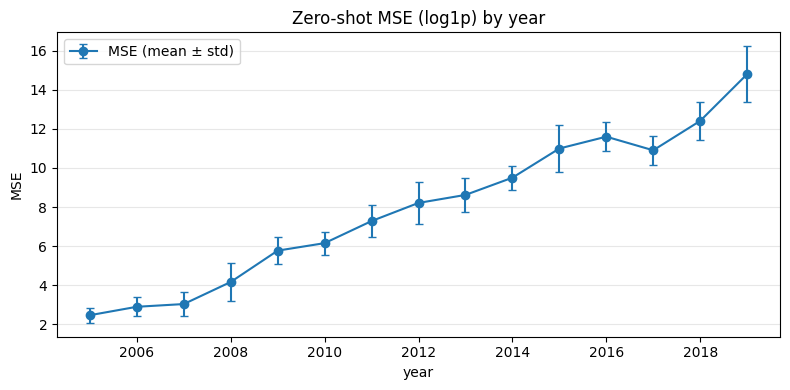

post_2005_plus aggregate:
          mse       mae      rmse    n
15   8.200380  2.630134  2.863631  437
31   8.010639  2.601134  2.830307  437
47   8.152102  2.587867  2.855189  437
63   8.139519  2.616045  2.852984  437
79   8.161542  2.611437  2.856841  437
95   8.270912  2.656764  2.875919  437
111  8.239784  2.646030  2.870502  437
127  8.148925  2.599746  2.854632  437
143  8.151845  2.598786  2.855144  437
159  8.245461  2.649048  2.871491  437
175  8.603847  2.694362  2.933231  437
191  7.998873  2.577211  2.828228  437
207  7.998642  2.612452  2.828187  437
223  7.723896  2.559656  2.779190  437
239  7.635569  2.515296  2.763253  437
255  7.665013  2.548589  2.768576  437
271  8.511001  2.686339  2.917362  437
287  8.454635  2.683198  2.907685  437
303  8.206148  2.620148  2.864638  437
319  8.328035  2.630182  2.885834  437


In [ ]:
# Purpose: plot zero-shot bucket metrics (if available)
# Zero-shot bucket plot
if BUCKET_METRICS_PATH.exists():
    bucket_df = pd.read_csv(BUCKET_METRICS_PATH)
elif "zero_shot_df" in globals() and zero_shot_df is not None:
    bucket_df = zero_shot_df.copy()
else:
    bucket_df = None

if bucket_df is None or bucket_df.empty:
    print("No bucket metrics to plot.")
else:
    if "method" in bucket_df.columns:
        bucket_df = bucket_df[bucket_df["method"] == "zero_shot"].copy()

    if "run_id" in bucket_df.columns:
        bucket_df = bucket_df.drop_duplicates(subset=["method", "year", "run_id"])

    bucket_df["year_num"] = pd.to_numeric(bucket_df["year"], errors="coerce")
    yearly = bucket_df[bucket_df["year_num"].notna()].copy()
    yearly["year_num"] = yearly["year_num"].astype(int)
    yearly = yearly.sort_values("year_num")

    if yearly.empty:
        print("No yearly buckets found for plot.")
    else:
        summary = (
            yearly.groupby("year_num")["mse"]
            .agg(mse_mean="mean", mse_std="std")
            .reset_index()
        )
        summary["mse_std"] = summary["mse_std"].fillna(0.0)

        lower_err = np.minimum(summary["mse_std"], summary["mse_mean"])
        upper_err = summary["mse_std"]

        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax1.errorbar(
            summary["year_num"],
            summary["mse_mean"],
            yerr=[lower_err, upper_err],
            marker="o",
            capsize=3,
            label="MSE (mean ± std)",
        )
        ax1.set_xlabel("year")
        ax1.set_ylabel("MSE")
        ax1.set_title("Zero-shot MSE (log1p) by year")
        ax1.grid(True, axis="y", alpha=0.3)
        ax1.legend(loc="upper left")
        plt.tight_layout()
        plot_path = paths.plots / "zero_shot_mse_by_year.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved plot to {plot_path}")
        plt.show()

    agg = bucket_df[bucket_df["year"] == "post_2005_plus"]
    if not agg.empty:
        print("post_2005_plus aggregate:")
        print(agg[["mse", "mae", "rmse", "n"]])


In [ ]:
# Purpose: finetune setup, loaders, and variant helpers
## Finetune setup + helpers

FINETUNE_BATCH_SIZE = 64
BASELINE_WEIGHT_DECAY = float(getattr(BASE_SHARED_TRAIN, "weight_decay", 0.0))
BASELINE_SCHEDULER_CFG = getattr(BASE_SHARED_TRAIN, "scheduler", None)


def build_plateau_scheduler(optimizer: torch.optim.Optimizer, sched_cfg: object) -> torch.optim.lr_scheduler.ReduceLROnPlateau | None:
    if sched_cfg is None:
        return None
    if isinstance(sched_cfg, dict):
        if not sched_cfg.get("enabled", True):
            return None
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=sched_cfg.get("mode", "min"),
            factor=sched_cfg.get("factor", 0.5),
            patience=sched_cfg.get("patience", 8),
            min_lr=sched_cfg.get("min_lr", 1e-6),
            threshold=sched_cfg.get("threshold", 1e-4),
        )
    enabled = getattr(sched_cfg, "enabled", True)
    if not enabled:
        return None
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=getattr(sched_cfg, "mode", "min"),
        factor=getattr(sched_cfg, "factor", 0.5),
        patience=getattr(sched_cfg, "patience", 8),
        min_lr=getattr(sched_cfg, "min_lr", 1e-6),
        threshold=getattr(sched_cfg, "threshold", 1e-4),
    )


def get_pretrain_artifacts(pretrain_run: Dict[str, object] | None, paths: NotebookPaths) -> Dict[str, object]:
    if pretrain_run is None:
        raise ValueError("Pretrain run is missing; run pretraining or load baseline model first.")
    artifacts = pretrain_run.get("features", {}).get("artifacts")
    if artifacts is None:
        artifacts_path = paths.checkpoints / "pretrain_shared_artifacts.pt"
        if artifacts_path.exists():
            artifacts = load_artifacts(artifacts_path)
    if artifacts is None:
        raise ValueError("Missing pretrain artifacts for feature encoding.")
    return artifacts


def build_pretrained_model(pretrain_run: Dict[str, object], device: str) -> torch.nn.Module:
    train_cfg = pretrain_run.get("train_cfg", BASE_SHARED_TRAIN)
    ckpt_path = pretrain_run.get("ckpt_path")
    if ckpt_path is not None:
        model = restore_pretrained(train_cfg, ckpt_path)
    else:
        model = deepcopy(pretrain_run["model"])
        model.to(device)
    return model


def build_finetune_loaders(
    artifacts: Dict[str, object],
    data_frac: float,
    seed: int,
    batch_size: int,
) -> Tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader, torch.utils.data.DataLoader, Dict[str, int]]:
    splits = load_post2005_split_dfs()
    train_df = splits["train"].copy()
    if data_frac < 1.0:
        train_df = train_df.sample(frac=data_frac, random_state=seed)
    val_df = splits["val"].copy()
    test_df = splits["test"].copy()

    X_train, y_train = apply_feature_artifacts(train_df, artifacts)
    X_val, y_val = apply_feature_artifacts(val_df, artifacts)
    X_test, y_test = apply_feature_artifacts(test_df, artifacts)

    train_loader = tensor_loader_from_arrays(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = tensor_loader_from_arrays(X_val, y_val, batch_size=batch_size, shuffle=False)
    test_loader = tensor_loader_from_arrays(X_test, y_test, batch_size=batch_size, shuffle=False)
    sizes = {"train": len(train_df), "val": len(val_df), "test": len(test_df)}
    return train_loader, val_loader, test_loader, sizes


def apply_variant_setup(
    model: torch.nn.Module,
    variant_name: str,
    adapter_cfg: AdapterConfig | None,
    max_updates: int,
) -> Dict[str, int | None]:
    variant = variant_name.lower()
    unfreeze_step = None

    if variant == "full_finetune":
        for param in model.parameters():
            param.requires_grad = True
    elif variant == "head_only":
        for param in model.encoder.parameters():
            param.requires_grad = False
        for param in model.head.parameters():
            param.requires_grad = True
    elif variant in ("lora", "dora"):
        if adapter_cfg is None:
            raise ValueError("adapter_cfg required for LoRA/DoRA variants")
        apply_adapters_to_model(model, adapter_cfg)
    elif variant == "gradual_unfreeze":
        for param in model.encoder.parameters():
            param.requires_grad = False
        for param in model.head.parameters():
            param.requires_grad = True
        unfreeze_step = max(50, int(0.30 * max_updates))
    else:
        raise ValueError(f"Unknown finetune variant: {variant_name}")

    return {"unfreeze_step": unfreeze_step}


def count_params(model: torch.nn.Module) -> Tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def finetune_shared_model_by_updates(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    lr: float,
    max_updates: int,
    val_every_steps: int,
    device: str,
    restore_best: bool = True,
    unfreeze_step: int | None = None,
    rebuild_optimizer_fn: Callable[[torch.nn.Module, float], torch.optim.Optimizer] | None = None,
    scheduler_fn: Callable[[torch.optim.Optimizer], object] | None = None,
    on_unfreeze: Callable[[torch.nn.Module, int], None] | None = None,
) -> Dict[str, object]:
    model.to(device)
    loss_fn = torch.nn.MSELoss()

    if rebuild_optimizer_fn is None:
        def rebuild_optimizer_fn(m: torch.nn.Module, lr_value: float):
            params = [p for p in m.parameters() if p.requires_grad]
            return torch.optim.AdamW(params, lr=lr_value, weight_decay=BASELINE_WEIGHT_DECAY)

    opt = rebuild_optimizer_fn(model, lr)
    scheduler = scheduler_fn(opt) if scheduler_fn else None

    history = {"global_step": [], "val_mse": [], "val_mae": []}
    best_val_mse = float("inf")
    best_val_step = None
    best_state = None
    last_val_step = None
    global_step = 0
    start_time = time.time()

    def run_validation(step: int):
        nonlocal best_val_mse, best_val_step, best_state, last_val_step
        metrics = evaluate_shared(model, val_loader, device)
        history["global_step"].append(step)
        history["val_mse"].append(metrics["mse"])
        history["val_mae"].append(metrics["mae"])
        last_val_step = step
        if scheduler is not None:
            scheduler.step(metrics["mse"])
        if metrics["mse"] < best_val_mse:
            best_val_mse = metrics["mse"]
            best_val_step = step
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    while global_step < max_updates:
        for batch in train_loader:
            if global_step >= max_updates:
                break
            model.train()
            xb, yb = batch
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb).squeeze(-1)
            loss = loss_fn(preds, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            global_step += 1

            if unfreeze_step is not None and global_step == unfreeze_step:
                for param in model.encoder.parameters():
                    param.requires_grad = True
                if on_unfreeze is not None:
                    on_unfreeze(model, global_step)
                opt = rebuild_optimizer_fn(model, lr)
                scheduler = scheduler_fn(opt) if scheduler_fn else None

            if val_every_steps and global_step % val_every_steps == 0:
                model.eval()
                run_validation(global_step)

    if last_val_step != global_step:
        model.eval()
        run_validation(global_step)

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)

    wall_time_s = time.time() - start_time
    return {
        "best_val_mse": best_val_mse,
        "best_val_step": best_val_step,
        "history": history,
        "final_global_step": global_step,
        "wall_time_s": wall_time_s,
    }


def run_finetune_variant(
    method: str,
    hp_cfg: Dict[str, object],
    data_frac: float,
    max_updates: int,
    val_every_steps: int,
    seed: int,
    pretrain_run: Dict[str, object],
    paths: NotebookPaths,
    device: str,
    eval_test: bool = True,
    save_checkpoint: bool = False,
    checkpoint_name: str | None = None,
    save_config: bool = False,
    use_plateau_scheduler: bool = False,
) -> Dict[str, object]:
    set_deterministic_seed(seed)
    artifacts = get_pretrain_artifacts(pretrain_run, paths)

    train_loader, val_loader, test_loader, sizes = build_finetune_loaders(
        artifacts,
        data_frac=data_frac,
        seed=seed,
        batch_size=FINETUNE_BATCH_SIZE,
    )

    model = build_pretrained_model(pretrain_run, device)

    adapter_cfg = hp_cfg.get("adapter_cfg")
    if adapter_cfg is None and method in ("lora", "dora"):
        adapter_cfg = AdapterConfig(
            adapter=method,
            rank=int(hp_cfg["rank"]),
            alpha=float(hp_cfg["alpha"]),
            dropout=0.0,
            train_bias=False,
            train_base=False,
        )

    setup_meta = apply_variant_setup(model, method, adapter_cfg, max_updates)
    total_params, trainable_params_initial = count_params(model)
    trainable_params_max = trainable_params_initial

    def on_unfreeze(m: torch.nn.Module, step: int) -> None:
        nonlocal trainable_params_max
        _, trainable_params_max = count_params(m)

    def rebuild_optimizer(m: torch.nn.Module, lr_value: float):
        params = [p for p in m.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=lr_value, weight_decay=BASELINE_WEIGHT_DECAY)

    scheduler_fn = None
    if use_plateau_scheduler:
        scheduler_fn = lambda opt: build_plateau_scheduler(opt, BASELINE_SCHEDULER_CFG)

    finetune_out = finetune_shared_model_by_updates(
        model,
        train_loader,
        val_loader,
        lr=float(hp_cfg["lr"]),
        max_updates=max_updates,
        val_every_steps=val_every_steps,
        device=device,
        restore_best=True,
        unfreeze_step=setup_meta.get("unfreeze_step"),
        rebuild_optimizer_fn=rebuild_optimizer,
        scheduler_fn=scheduler_fn,
        on_unfreeze=on_unfreeze,
    )

    test_metrics = None
    if eval_test:
        test_metrics = evaluate_shared(model, test_loader, device)

    run_payload = {
        "method": method,
        "data_frac": data_frac,
        "max_updates": max_updates,
        "seed": seed,
        "hp_cfg": hp_cfg,
        "batch_size": FINETUNE_BATCH_SIZE,
    }
    run_id = make_run_id(run_payload)

    if save_checkpoint and not checkpoint_name:
        raise ValueError("checkpoint_name is required when save_checkpoint is True")

    if save_checkpoint:
        ckpt_path = paths.checkpoints / f"finetune_{checkpoint_name}.pt"
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "run_payload": run_payload,
                "trainable_params_initial": trainable_params_initial,
                "trainable_params_max": trainable_params_max,
                "best_val_mse": finetune_out["best_val_mse"],
                "best_val_step": finetune_out["best_val_step"],
            },
            ckpt_path,
        )
    else:
        ckpt_path = None

    if save_config:
        config_payload = {
            **run_payload,
            "total_params": total_params,
            "trainable_params_initial": trainable_params_initial,
            "trainable_params_max": trainable_params_max,
            "best_val_mse": finetune_out["best_val_mse"],
            "best_val_step": finetune_out["best_val_step"],
            "final_global_step": finetune_out["final_global_step"],
            "wall_time_s": finetune_out["wall_time_s"],
            "unfreeze_step": setup_meta.get("unfreeze_step"),
            "split_sizes": sizes,
        }
        config_dir = paths.results / "finetune_configs"
        config_dir.mkdir(parents=True, exist_ok=True)
        (config_dir / f"finetune_{run_id}.json").write_text(json.dumps(config_payload, indent=2))

    return {
        "run_id": run_id,
        "method": method,
        "data_frac": data_frac,
        "max_updates": max_updates,
        "seed": seed,
        "total_params": total_params,
        "trainable_params_initial": trainable_params_initial,
        "trainable_params_max": trainable_params_max,
        "best_val_mse": finetune_out["best_val_mse"],
        "best_val_step": finetune_out["best_val_step"],
        "history": finetune_out["history"],
        "final_global_step": finetune_out["final_global_step"],
        "wall_time_s": finetune_out["wall_time_s"],
        "unfreeze_step": setup_meta.get("unfreeze_step"),
        "test_mse": None if test_metrics is None else test_metrics["mse"],
        "test_mae": None if test_metrics is None else test_metrics["mae"],
        "split_sizes": sizes,
        "checkpoint_path": str(ckpt_path) if ckpt_path is not None else None,
    }


In [ ]:
# Purpose: optional hyperparameter tuning on validation only
## Hyperparameter tuning (validation only)

RUN_TUNING = False
TUNING_SEEDS = [0, 1]
TUNING_SCENARIOS = [
    {"name": "scenario_A", "data_frac": 1.0, "max_updates": 500, "val_every_steps": 20},
    {"name": "scenario_B", "data_frac": 0.25, "max_updates": 2000, "val_every_steps": 20},
]

FULL_FT_LRS = [1e-3, 3e-4, 1e-4]
HEAD_ONLY_LRS = [3e-3, 1e-3, 3e-4]
ADAPTER_LRS = [1e-3, 3e-4]
ADAPTER_RANKS = [4, 8]


def build_tuning_grid() -> Dict[str, List[Dict[str, object]]]:
    grids = {
        "full_finetune": [{"lr": lr} for lr in FULL_FT_LRS],
        "gradual_unfreeze": [{"lr": lr} for lr in FULL_FT_LRS],
        "head_only": [{"lr": lr} for lr in HEAD_ONLY_LRS],
    }

    adapter_cfgs = []
    for lr, rank in product(ADAPTER_LRS, ADAPTER_RANKS):
        adapter_cfgs.append({"lr": lr, "rank": rank, "alpha": float(rank)})
        adapter_cfgs.append({"lr": lr, "rank": rank, "alpha": float(2 * rank)})

    grids["lora"] = adapter_cfgs
    grids["dora"] = adapter_cfgs
    return grids


best_hp_by_method: Dict[str, Dict[str, object]] | None = None

if RUN_TUNING:
    tuning_grids = build_tuning_grid()
    tuning_results = []
    best_hp_by_method = {}

    for method, grid in tuning_grids.items():
        best_record = None
        best_mean = float("inf")

        for hp in grid:
            val_scores = []
            for scenario in TUNING_SCENARIOS:
                for seed in TUNING_SEEDS:
                    result = run_finetune_variant(
                        method=method,
                        hp_cfg=hp,
                        data_frac=scenario["data_frac"],
                        max_updates=scenario["max_updates"],
                        val_every_steps=scenario["val_every_steps"],
                        seed=seed,
                        pretrain_run=PRETRAIN_RUN,
                        paths=paths,
                        device=cfg.device,
                        eval_test=False,
                    )
                    val_scores.append(result["best_val_mse"])

            mean_val = float(np.mean(val_scores))
            tuning_results.append({"method": method, "hp": hp, "mean_val_mse": mean_val})
            if mean_val < best_mean:
                best_mean = mean_val
                best_record = hp

        if best_record is None:
            raise RuntimeError(f"No tuning results for method={method}")
        best_hp_by_method[method] = best_record
        print(f"Best HP for {method}: {best_record} (mean val MSE={best_mean:.4f})")

    BEST_HP_PATH = paths.results / "best_hp_by_method.json"
    BEST_HP_PATH.write_text(json.dumps(best_hp_by_method, indent=2))
else:
    BEST_HP_PATH = paths.results / "best_hp_by_method.json"
    if BEST_HP_PATH.exists():
        with BEST_HP_PATH.open("r") as f:
            best_hp_by_method = json.load(f)
        print(f"Loaded best_hp_by_method from {BEST_HP_PATH}")
    else:
        print("Tuning skipped. Ensure best_hp_by_method is loaded manually.")

assert best_hp_by_method is not None and len(best_hp_by_method) > 0, "Tuning must complete before experiments."


Loaded best_hp_by_method from c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\best_hp_by_method.json


In [ ]:
# Purpose: run final finetune experiments (or load cached results)
## Final experiments (use tuned hyperparameters only)

RUN_FINAL_EXPERIMENTS = True
SAVE_FINAL_CONFIGS = False
SAVE_FINAL_CHECKPOINTS = True
SAVE_FINAL_PLOTS = True

METHODS = ["full_finetune", "gradual_unfreeze", "head_only", "lora", "dora"]
RUN_EXP_A = False
EXP_A_BUDGETS = [50, 100, 200, 500, 1000, 2000, 5000]
EXP_A_VAL_EVERY = 20
EXP_A_SEEDS = [0, 1, 2]

RUN_EXP_B = False
EXP_B_FRACS = [0.02, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25, 0.3, 0.5, 1.0]
EXP_B_MAX_UPDATES = 2000
EXP_B_VAL_EVERY = 20


def seeds_for_frac(frac: float) -> List[int]:
    return [0, 1, 2, 3, 4] if frac <= 0.25 else [0, 1, 2]


all_runs = []

if RUN_FINAL_EXPERIMENTS:
    assert best_hp_by_method is not None and len(best_hp_by_method) > 0, "Tuning must complete before experiments."

    # Experiment A: low training budget sweep
    if RUN_EXP_A:
        for method in METHODS:
            hp_cfg = best_hp_by_method[method]
            for max_updates in EXP_A_BUDGETS:
                for seed in EXP_A_SEEDS:
                    print(f"Running Experiment A: method={method}, max_updates={max_updates}, seed={seed}")
                    t0 = time.time()
                    result = run_finetune_variant(
                        method=method,
                        hp_cfg=hp_cfg,
                        data_frac=1.0,
                        max_updates=max_updates,
                        val_every_steps=EXP_A_VAL_EVERY,
                        seed=seed,
                        pretrain_run=PRETRAIN_RUN,
                        paths=paths,
                        device=cfg.device,
                        eval_test=True,
                        save_checkpoint=SAVE_FINAL_CHECKPOINTS,
                        checkpoint_name=f"{method}_budget{max_updates}_seed{seed}",
                        save_config=SAVE_FINAL_CONFIGS,
                    )
                    print(f"Run took {time.time() - t0:.2f} seconds")
                    result["experiment_type"] = "low_budget"
                    all_runs.append(result)
    else:
        print("Skipping Experiment A")                
    

    # Experiment B: small dataset sweep
    if RUN_EXP_B:
        for method in METHODS:
            hp_cfg = best_hp_by_method[method]
            for frac in EXP_B_FRACS:
                for seed in seeds_for_frac(frac):
                    print(f"Running Experiment B: method={method}, frac={frac}, seed={seed}")
                    t0 = time.time()
                    result = run_finetune_variant(
                        method=method,
                        hp_cfg=hp_cfg,
                        data_frac=frac,
                        max_updates=EXP_B_MAX_UPDATES,
                        val_every_steps=EXP_B_VAL_EVERY,
                        seed=seed,
                        pretrain_run=PRETRAIN_RUN,
                        paths=paths,
                        device=cfg.device,
                        eval_test=True,
                        save_checkpoint=SAVE_FINAL_CHECKPOINTS,
                        checkpoint_name=f"{method}_frac{frac}_seed{seed}",
                        save_config=SAVE_FINAL_CONFIGS,
                        use_plateau_scheduler=True,
                    )
                    print(f"Run took {time.time() - t0:.2f} seconds")
                    result["experiment_type"] = "small_data"
                    all_runs.append(result)
    else:
        print("Skipping Experiment B")    
else:
    print("Final experiments skipped.")


results_df = pd.DataFrame(all_runs)

cached_frames = []
if (not RUN_FINAL_EXPERIMENTS) or (not RUN_EXP_A):
    exp_a_path = paths.results / "finetune_results_expA.csv"
    if exp_a_path.exists():
        cached_frames.append(pd.read_csv(exp_a_path))
        print(f"Loaded cached Experiment A results from {exp_a_path}")
    else:
        print(f"Cached Experiment A results not found at {exp_a_path}")

if (not RUN_FINAL_EXPERIMENTS) or (not RUN_EXP_B):
    exp_b_path = paths.results / "finetune_results_expB.csv"
    if exp_b_path.exists():
        cached_frames.append(pd.read_csv(exp_b_path))
        print(f"Loaded cached Experiment B results from {exp_b_path}")
    else:
        print(f"Cached Experiment B results not found at {exp_b_path}")

if cached_frames:
    cached_df = pd.concat(cached_frames, ignore_index=True)
    if results_df.empty:
        results_df = cached_df
    else:
        results_df = pd.concat([results_df, cached_df], ignore_index=True)

if not results_df.empty:
    unfreeze_steps = results_df["unfreeze_step"].fillna(results_df["max_updates"])
    steps_after_unfreeze = (results_df["max_updates"] - unfreeze_steps).clip(lower=0)
    results_df["pseudo_compute"] = (
        results_df["trainable_params_initial"] * unfreeze_steps
        + results_df["trainable_params_max"] * steps_after_unfreeze
    )

    results_path = paths.results / "finetune_results.csv"
    results_df.to_csv(results_path, index=False)
    print(f"Saved finetune results to {results_path}")

    exp_a_results = results_df[results_df["experiment_type"] == "low_budget"].copy()
    exp_b_results = results_df[results_df["experiment_type"] == "small_data"].copy()

    if not exp_a_results.empty:
        exp_a_path = paths.results / "finetune_results_expA.csv"
        exp_a_results.to_csv(exp_a_path, index=False)
        print(f"Saved experiment A results to {exp_a_path}")

    if not exp_b_results.empty:
        exp_b_path = paths.results / "finetune_results_expB.csv"
        exp_b_results.to_csv(exp_b_path, index=False)
        print(f"Saved experiment B results to {exp_b_path}")

    print(results_df.head())


Skipping Experiment A
Skipping Experiment B
Loaded cached Experiment A results from c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\finetune_results_expA.csv
Loaded cached Experiment B results from c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\finetune_results_expB.csv
Saved finetune results to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\finetune_results.csv
Saved experiment A results to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\finetune_results_expA.csv
Saved experiment B results to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\results\finetune_results_expB.csv
         run_id         method  data_fra

Saved plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\expA_test_mse_vs_max_updates.png


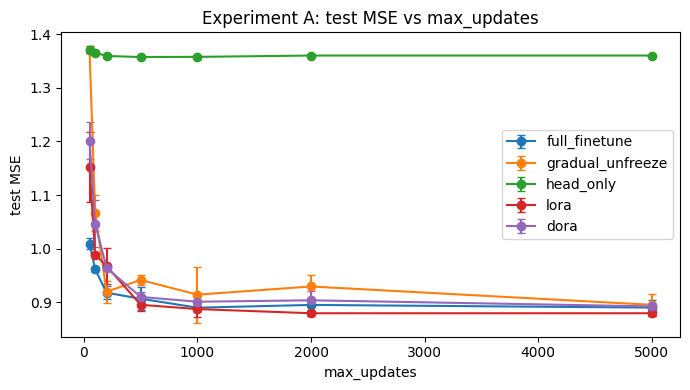

Saved plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\expA_test_mse_vs_pseudo_compute.png


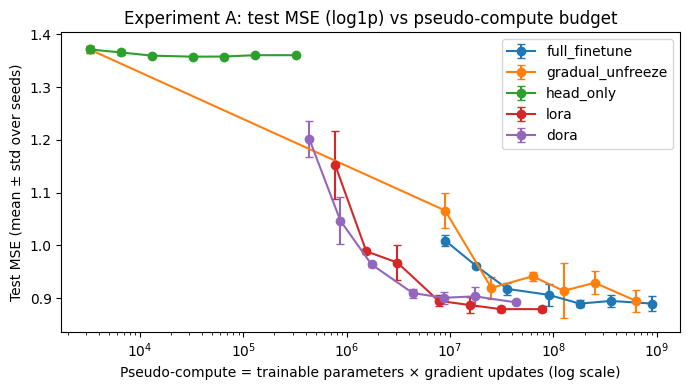

Saved plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\expB_test_mse_vs_data_frac.png


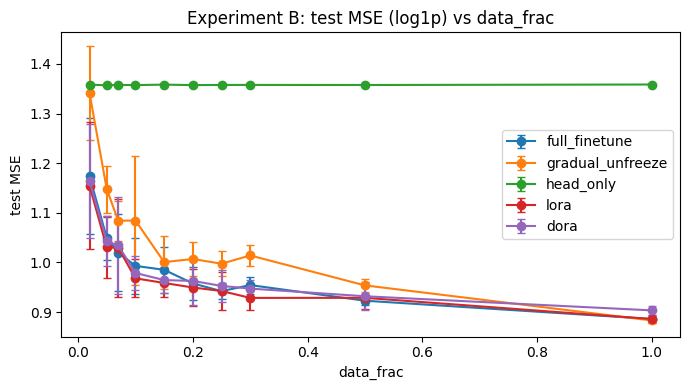

Saved plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\pretrained_finetune\plots\expB_test_mse_vs_pseudo_compute.png


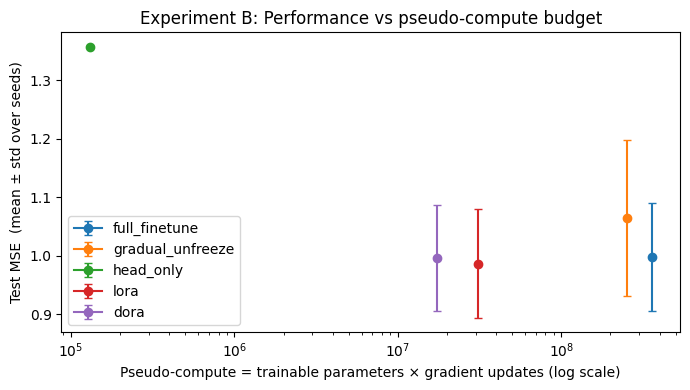

             method  trainable_params_initial  trainable_params_max  \
0     full_finetune                    179201                179201   
1  gradual_unfreeze                        65                179201   
2         head_only                        65                    65   
3              lora                     15464                 15464   
4              dora                      8693                  8693   

  expA_test_mse@1000 expB_test_mse@1.0  
0      0.8897±0.0072     0.8861±0.0032  
1      0.9140±0.0524     0.8831±0.0026  
2      1.3578±0.0019     1.3587±0.0004  
3      0.8871±0.0149     0.8860±0.0075  
4      0.9008±0.0118     0.9035±0.0083  


In [ ]:
# Purpose: aggregate results and generate plots/summaries
## Results dataframe + plots

if results_df.empty:
    print("No results to plot.")
else:
    exp_a = results_df[results_df["experiment_type"] == "low_budget"].copy()
    exp_b = results_df[results_df["experiment_type"] == "small_data"].copy()

    exp_a_summary = (
        exp_a.groupby(["method", "max_updates"])["test_mse"]
        .agg(["mean", "std"])
        .reset_index()
    )

    unfreeze_steps = exp_a["unfreeze_step"].fillna(exp_a["max_updates"])
    steps_after_unfreeze = (exp_a["max_updates"] - unfreeze_steps).clip(lower=0)
    exp_a["pseudo_compute"] = (
        exp_a["trainable_params_initial"] * unfreeze_steps
        + exp_a["trainable_params_max"] * steps_after_unfreeze
    )
    exp_a_pc_summary = (
        exp_a.groupby(["method", "pseudo_compute"])["test_mse"]
        .agg(["mean", "std"])
        .reset_index()
    )

    exp_b_summary = (
        exp_b.groupby(["method", "data_frac"])["test_mse"]
        .agg(["mean", "std"])
        .reset_index()
    )

    if "pseudo_compute" not in exp_b.columns:
        unfreeze_steps = exp_b["unfreeze_step"].fillna(exp_b["max_updates"])
        steps_after_unfreeze = (exp_b["max_updates"] - unfreeze_steps).clip(lower=0)
        exp_b["pseudo_compute"] = (
            exp_b["trainable_params_initial"] * unfreeze_steps
            + exp_b["trainable_params_max"] * steps_after_unfreeze
        )

    exp_b_pc_summary = (
        exp_b.groupby(["method", "pseudo_compute"])["test_mse"]
        .agg(["mean", "std"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    for method in METHODS:
        subset = exp_a_summary[exp_a_summary["method"] == method]
        if subset.empty:
            continue
        ax.errorbar(
            subset["max_updates"],
            subset["mean"],
            yerr=subset["std"],
            marker="o",
            capsize=3,
            label=method,
        )
    ax.set_title("Experiment A: test MSE vs max_updates")
    ax.set_xlabel("max_updates")
    ax.set_ylabel("test MSE")
    ax.legend()
    plt.tight_layout()
    if SAVE_FINAL_PLOTS:
        plot_path = paths.plots / "expA_test_mse_vs_max_updates.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved plot to {plot_path}")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    for method in METHODS:
        subset = exp_a_pc_summary[exp_a_pc_summary["method"] == method]
        if subset.empty:
            continue
        ax.errorbar(
            subset["pseudo_compute"],
            subset["mean"],
            yerr=subset["std"],
            marker="o",
            capsize=3,
            label=method,
        )
    ax.set_xscale("log")
    ax.set_title("Experiment A: test MSE (log1p) vs pseudo-compute budget")
    ax.set_xlabel(
        "Pseudo-compute = trainable parameters × gradient updates (log scale)"
    )
    ax.set_ylabel("Test MSE (mean ± std over seeds)")
    ax.legend()
    plt.tight_layout()
    if SAVE_FINAL_PLOTS:
        plot_path = paths.plots / "expA_test_mse_vs_pseudo_compute.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved plot to {plot_path}")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    for method in METHODS:
        subset = exp_b_summary[exp_b_summary["method"] == method]
        if subset.empty:
            continue
        ax.errorbar(
            subset["data_frac"],
            subset["mean"],
            yerr=subset["std"],
            marker="o",
            capsize=3,
            label=method,
        )
    ax.set_title("Experiment B: test MSE (log1p) vs data_frac")
    ax.set_xlabel("data_frac")
    ax.set_ylabel("test MSE")
    ax.legend()
    plt.tight_layout()
    if SAVE_FINAL_PLOTS:
        plot_path = paths.plots / "expB_test_mse_vs_data_frac.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved plot to {plot_path}")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    for method in METHODS:
        subset = exp_b_pc_summary[exp_b_pc_summary["method"] == method]
        if subset.empty:
            continue
        ax.errorbar(
            subset["pseudo_compute"],
            subset["mean"],
            yerr=subset["std"],
            marker="o",
            capsize=3,
            label=method,
        )
    ax.set_xscale("log")
    ax.set_title("Experiment B: Performance vs pseudo-compute budget")
    ax.set_xlabel(
        "Pseudo-compute = trainable parameters × gradient updates (log scale)"
    )
    ax.set_ylabel("Test MSE  (mean ± std over seeds)")
    ax.legend()
    plt.tight_layout()
    if SAVE_FINAL_PLOTS:
        plot_path = paths.plots / "expB_test_mse_vs_pseudo_compute.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved plot to {plot_path}")
    plt.show()

    # Summary table
    summary_rows = []
    for method in METHODS:
        method_rows = results_df[results_df["method"] == method]
        if method_rows.empty:
            continue
        params_initial = int(method_rows["trainable_params_initial"].iloc[0])
        params_max = int(method_rows["trainable_params_max"].iloc[0])

        exp_a_1000 = exp_a[(exp_a["method"] == method) & (exp_a["max_updates"] == 1000)]
        a_mean = exp_a_1000["test_mse"].mean()
        a_std = exp_a_1000["test_mse"].std()

        exp_b_full = exp_b[(exp_b["method"] == method) & (exp_b["data_frac"] == 1.0)]
        b_mean = exp_b_full["test_mse"].mean()
        b_std = exp_b_full["test_mse"].std()

        summary_rows.append(
            {
                "method": method,
                "trainable_params_initial": params_initial,
                "trainable_params_max": params_max,
                "expA_test_mse@1000": f"{a_mean:.4f}±{a_std:.4f}",
                "expB_test_mse@1.0": f"{b_mean:.4f}±{b_std:.4f}",
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df)
